# Test combining MCS masks over time with HEALPix data
- Get a 6-hour chunk from MCS mask on HEALPix zoom 8 Zarr store
- Apply create_track_swaths_and_coverage() and combine_swaths_with_priority() functions
- Visualize the results

### Author: 
- Zhe Feng <zhe.feng@pnnl.gov>


In [76]:
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

In [77]:
source_name = "scream"
zoom = 8
source_res = f"ne120_inst_ivt_hp{zoom}"
dir_mcs = f"/pscratch/sd/w/wcmca1/scream-cess-healpix/mcs_tracking_hp9/mcstracking/{source_name}2D_hrly_mcsmask_hp8_v1.zarr"

### 1. Read in MCS mask data 

In [78]:
ds = xr.open_zarr(dir_mcs, consolidated=True, mask_and_scale=False)
ncells = ds.sizes['cell']
ds

<xarray.Dataset> Size: 119GB
Dimensions:   (time: 9456, cell: 786432)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    crs       int64 8B ...
  * time      (time) datetime64[ns] 76kB 2019-08-01T01:00:00 ... 2020-09-01
Data variables:
    ccs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
    mcs_mask  (time, cell) int64 59GB dask.array<chunksize=(24, 65536), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon May  5 10:42:36 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [81]:
# Subset a 6-h period for testing
_mcs_mask = ds.mcs_mask.sel(time=slice('2019-08-10T00', '2019-08-10T05')).compute()
_ccs_mask = ds.ccs_mask.sel(time=slice('2019-08-10T00', '2019-08-10T05')).compute()
_mcs_mask

<xarray.DataArray 'mcs_mask' (time: 6, cell: 786432)> Size: 38MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    crs      int64 8B 0
  * time     (time) datetime64[ns] 48B 2019-08-10 ... 2019-08-10T05:00:00
Attributes:
    comments:    This mask renumbers small merge/split tracks to the main tra...
    long_name:   Track number including merge/split
    units:       unitless
    _FillValue:  0

In [80]:
# Check the shape of track number array
print(f"Track number array shape: {_mcs_mask.shape}")
print(f"Unique track numbers: {np.unique(_mcs_mask)}")
print(f"Track number data type: {_mcs_mask.dtype}")

Track number array shape: (6, 786432)
Unique track numbers: [   0  479  759  962 1037 1154 1255 1276 1287 1302 1303 1306 1325 1332
 1335 1340 1343 1345 1350 1356 1359 1360 1367 1373 1375 1379 1383 1391
 1394 1398 1399 1400 1401 1403 1410 1411 1412 1413 1414 1416 1417 1418
 1421 1425 1428 1429 1432 1434 1436 1437 1440 1441 1442 1446 1447 1448
 1449 1450 1452 1454 1455 1456 1458 1459 1460 1462 1463 1464 1467 1468
 1469 1472 1473 1474 1475 1476 1477 1478 1479 1480 1481 1482 1484 1485
 1486 1487 1488 1489 1490 1491 1492 1493 1494 1495 1496 1497 1498 1499
 1500 1501 1502 1503 1504 1505 1506 1507 1508 1509 1510 1511 1512 1513
 1514 1515 1516 1517 1518 1519 1520 1521 1522 1523 1524 1525 1526 1527
 1528 1529 1530 1531 1532 1533 1534 1535 1536 1537 1538 1539 1540 1541
 1542]
Track number data type: int64


### 2. Create Track Swaths Function

This section creates a function to generate track swaths and coverage counts from track number arrays.

In [88]:
def create_track_swaths_and_coverage(tracknumber):
    """
    Create track swaths and coverage count arrays from a 3D track number array.
    
    Parameters:
    -----------
    tracknumber : numpy.ndarray
        3D array with dimensions (time, y, x) containing track numbers at each timestep.
        Background/no-track pixels should be 0.
    
    Returns:
    --------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values.
        Each swath shows all pixels covered by that track (labeled with track_id).
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values.
        Each array shows the number of timesteps each pixel was covered by that track.
    
    Example:
    --------
    >>> tracknumber = np.zeros((24, 200, 150), dtype=int)
    >>> # ... populate tracknumber with track data ...
    >>> swaths, coverage = create_track_swaths_and_coverage(tracknumber)
    """
    # Get unique track numbers (excluding 0 which is background)
    unique_tracks = np.unique(tracknumber)
    unique_tracks = unique_tracks[unique_tracks > 0]
    
    # Initialize dictionaries
    track_swaths_dict = {}
    track_coverage_dict = {}
    
    # Process each unique track using vectorized operations
    for track_id in unique_tracks:
        # Create binary mask for this track across all timesteps
        track_mask = (tracknumber == track_id).astype(int)
        
        # Track swath: all pixels covered by this track labeled with track number
        swath = np.any(track_mask, axis=0).astype(int) * track_id
        track_swaths_dict[track_id] = swath
        
        # Coverage count: number of times each pixel is covered
        coverage = np.sum(track_mask, axis=0)
        track_coverage_dict[track_id] = coverage
    
    return track_swaths_dict, track_coverage_dict

In [89]:
%%timeit

# Apply the function to create track swaths and coverage
track_swaths_dict, track_coverage_dict = create_track_swaths_and_coverage(_mcs_mask.values)

4.11 s ± 35 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [90]:
# Get unique track numbers for reference
unique_tracks = np.unique(_mcs_mask)
unique_tracks = unique_tracks[unique_tracks > 0]

print(f"Number of unique tracks: {len(unique_tracks)}")
print(f"Unique tracks: {unique_tracks}")

Number of unique tracks: 140
Unique tracks: [ 479  759  962 1037 1154 1255 1276 1287 1302 1303 1306 1325 1332 1335
 1340 1343 1345 1350 1356 1359 1360 1367 1373 1375 1379 1383 1391 1394
 1398 1399 1400 1401 1403 1410 1411 1412 1413 1414 1416 1417 1418 1421
 1425 1428 1429 1432 1434 1436 1437 1440 1441 1442 1446 1447 1448 1449
 1450 1452 1454 1455 1456 1458 1459 1460 1462 1463 1464 1467 1468 1469
 1472 1473 1474 1475 1476 1477 1478 1479 1480 1481 1482 1484 1485 1486
 1487 1488 1489 1490 1491 1492 1493 1494 1495 1496 1497 1498 1499 1500
 1501 1502 1503 1504 1505 1506 1507 1508 1509 1510 1511 1512 1513 1514
 1515 1516 1517 1518 1519 1520 1521 1522 1523 1524 1525 1526 1527 1528
 1529 1530 1531 1532 1533 1534 1535 1536 1537 1538 1539 1540 1541 1542]


### 3. Visualize Track Swaths

This section visualizes the swath for each unique track.

In [91]:
# Calculate combined arrays for visualization
track_swath = np.zeros((ncells), dtype=int)
track_coverage = np.zeros((ncells), dtype=int)

for track_id in unique_tracks:
    swath = track_swaths_dict[track_id]
    coverage = track_coverage_dict[track_id]
    track_swath = np.where(swath > 0, track_id, track_swath)
    track_coverage += coverage

print(f"\nTrack swath shape: {track_swath.shape}")
print(f"Track coverage shape: {track_coverage.shape}")
print(f"Max coverage count: {np.max(track_coverage)}")

# Display summary for each track
for track_id in unique_tracks:
    swath_pixels = np.sum(track_swaths_dict[track_id] > 0)
    max_coverage = np.max(track_coverage_dict[track_id])
    print(f"Track {track_id}: {swath_pixels} pixels in swath, max coverage = {max_coverage} timesteps")


Track swath shape: (786432,)
Track coverage shape: (786432,)
Max coverage count: 6
Track 479: 325 pixels in swath, max coverage = 6 timesteps
Track 759: 910 pixels in swath, max coverage = 6 timesteps
Track 962: 626 pixels in swath, max coverage = 2 timesteps
Track 1037: 2 pixels in swath, max coverage = 1 timesteps
Track 1154: 2133 pixels in swath, max coverage = 6 timesteps
Track 1255: 808 pixels in swath, max coverage = 5 timesteps
Track 1276: 1110 pixels in swath, max coverage = 6 timesteps
Track 1287: 1470 pixels in swath, max coverage = 6 timesteps
Track 1302: 281 pixels in swath, max coverage = 6 timesteps
Track 1303: 623 pixels in swath, max coverage = 6 timesteps
Track 1306: 724 pixels in swath, max coverage = 6 timesteps
Track 1325: 175 pixels in swath, max coverage = 6 timesteps
Track 1332: 1765 pixels in swath, max coverage = 6 timesteps
Track 1335: 2252 pixels in swath, max coverage = 6 timesteps
Track 1340: 87 pixels in swath, max coverage = 3 timesteps
Track 1343: 402 p

<Figure size 921.6x691.2 with 0 Axes>

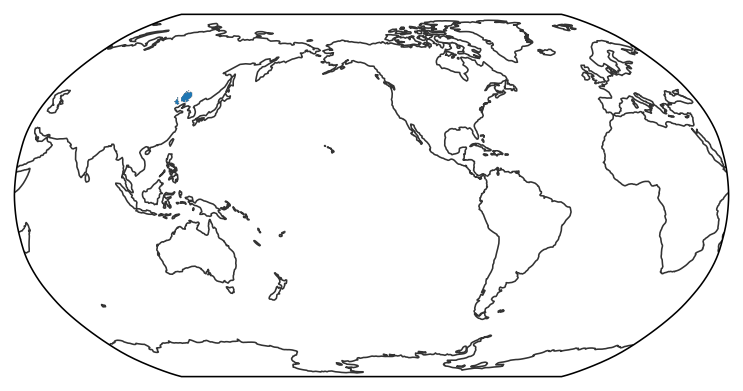

In [93]:
# Visualize a sample track swath
norm = mpl.colors.Normalize(vmin=np.min(unique_tracks), vmax=np.max(unique_tracks))

swath = track_swaths_dict[np.int64(479)]
swath = xr.DataArray(swath, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
egh.healpix_show(swath.where(swath > 0), norm=norm, cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

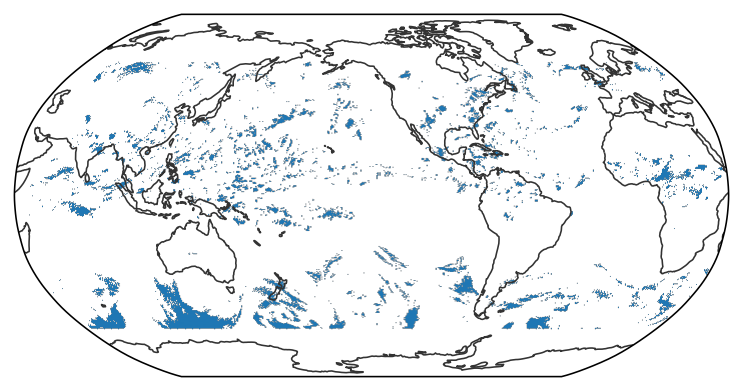

In [110]:
# Convert MCS swath to binary
track_swath_binary = (track_swath > 0).astype(int)
track_swath_binary = xr.DataArray(track_swath_binary, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
# Filter out CCS that overlap with MCS swaths
ccs_binary = _ccs_mask_sum.where(track_swath_binary == 0)
egh.healpix_show(ccs_binary.where(ccs_binary > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

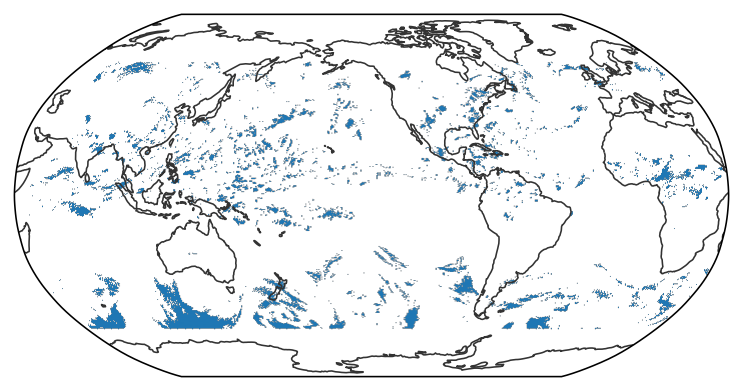

In [114]:
# Sum over time and convert to binary mask
_ccs_mask_sum = ((_ccs_mask > 0).sum(dim='time') > 0).values

track_swath_binary = (track_swath > 0).astype(int)
_ccs_mask_sum[track_swath_binary == 1] = 0

ccs_binary = xr.DataArray(_ccs_mask_sum, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
egh.healpix_show(ccs_binary.where(ccs_binary > 0), cmap='tab20')

0 479
1 759
2 962
3 1037
4 1154
5 1255
6 1276
7 1287
8 1302
9 1303
10 1306
11 1325
12 1332
13 1335
14 1340
15 1343
16 1345
17 1350
18 1356
19 1359
20 1360
21 1367
22 1373
23 1375
24 1379
25 1383
26 1391
27 1394
28 1398
29 1399
30 1400
31 1401
32 1403
33 1410
34 1411
35 1412
36 1413
37 1414
38 1416
39 1417
40 1418
41 1421
42 1425
43 1428
44 1429
45 1432
46 1434
47 1436
48 1437
49 1440
50 1441
51 1442
52 1446
53 1447
54 1448
55 1449
56 1450
57 1452
58 1454
59 1455
60 1456
61 1458
62 1459
63 1460
64 1462
65 1463
66 1464
67 1467
68 1468
69 1469
70 1472
71 1473
72 1474
73 1475
74 1476
75 1477
76 1478
77 1479
78 1480
79 1481
80 1482
81 1484
82 1485
83 1486
84 1487
85 1488
86 1489
87 1490
88 1491
89 1492
90 1493
91 1494
92 1495
93 1496
94 1497
95 1498
96 1499
97 1500
98 1501
99 1502
100 1503
101 1504
102 1505
103 1506
104 1507
105 1508
106 1509
107 1510
108 1511
109 1512
110 1513
111 1514
112 1515
113 1516
114 1517
115 1518
116 1519
117 1520
118 1521
119 1522
120 1523
121 1524
122 1525
123 15

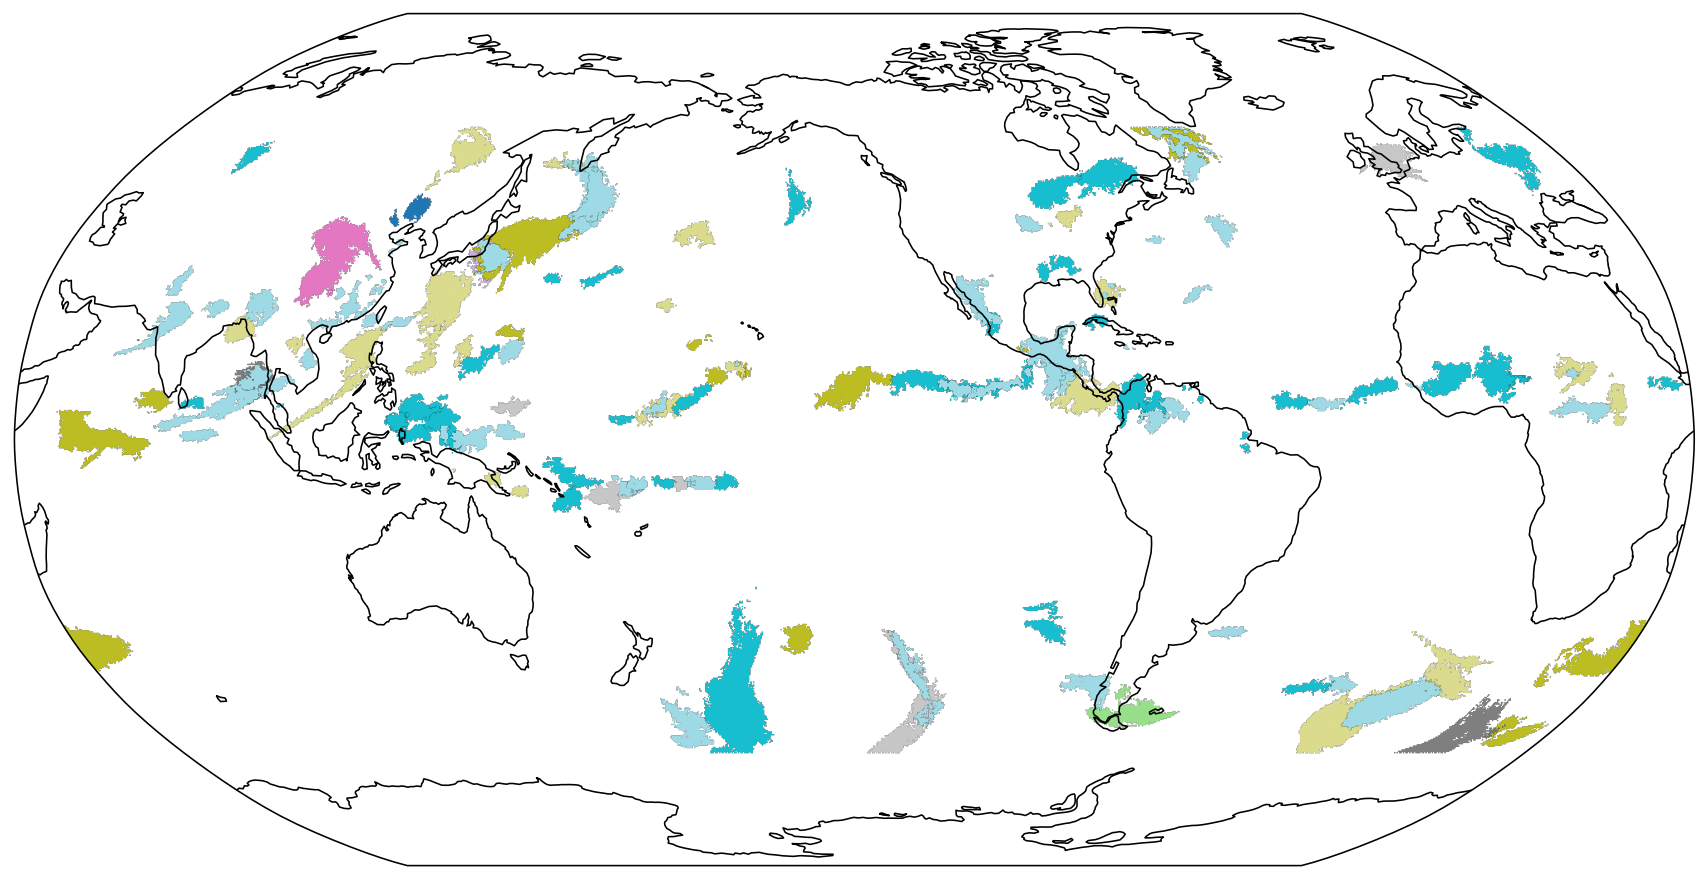

In [47]:
projection = ccrs.Robinson(central_longitude=-135)
fig, ax = plt.subplots(
    figsize=(12,6),
    subplot_kw={"projection": projection},
    constrained_layout=True
)
# fig.dpi = dpi
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)

# Normalize color scale
norm = mpl.colors.Normalize(vmin=np.min(unique_tracks), vmax=np.max(unique_tracks))

for i, track_id in enumerate(unique_tracks):
    print(i, track_id)
    swath = track_swaths_dict[track_id]
    # Convert to DataArray, attach coordinates
    swath = xr.DataArray(swath, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
    img = egh.healpix_show(swath.where(swath > 0), norm=norm, cmap='tab20', ax=ax)

0 479
1 759
2 962
3 1037
4 1154
5 1255
6 1276
7 1287
8 1302
9 1303
10 1306
11 1325
12 1332
13 1335
14 1340
15 1343
16 1345
17 1350
18 1356
19 1359
20 1360
21 1367
22 1373
23 1375
24 1379
25 1383
26 1391
27 1394
28 1398
29 1399
30 1400
31 1401
32 1403
33 1410
34 1411
35 1412
36 1413
37 1414
38 1416
39 1417
40 1418
41 1421
42 1425
43 1428
44 1429
45 1432
46 1434
47 1436
48 1437
49 1440
50 1441
51 1442
52 1446
53 1447
54 1448
55 1449
56 1450
57 1452
58 1454
59 1455
60 1456
61 1458
62 1459
63 1460
64 1462
65 1463
66 1464
67 1467
68 1468
69 1469
70 1472
71 1473
72 1474
73 1475
74 1476
75 1477
76 1478
77 1479
78 1480
79 1481
80 1482
81 1484
82 1485
83 1486
84 1487
85 1488
86 1489
87 1490
88 1491
89 1492
90 1493
91 1494
92 1495
93 1496
94 1497
95 1498
96 1499
97 1500
98 1501
99 1502
100 1503
101 1504
102 1505
103 1506
104 1507
105 1508
106 1509
107 1510
108 1511
109 1512
110 1513
111 1514
112 1515
113 1516
114 1517
115 1518
116 1519
117 1520
118 1521
119 1522
120 1523
121 1524
122 1525
123 15

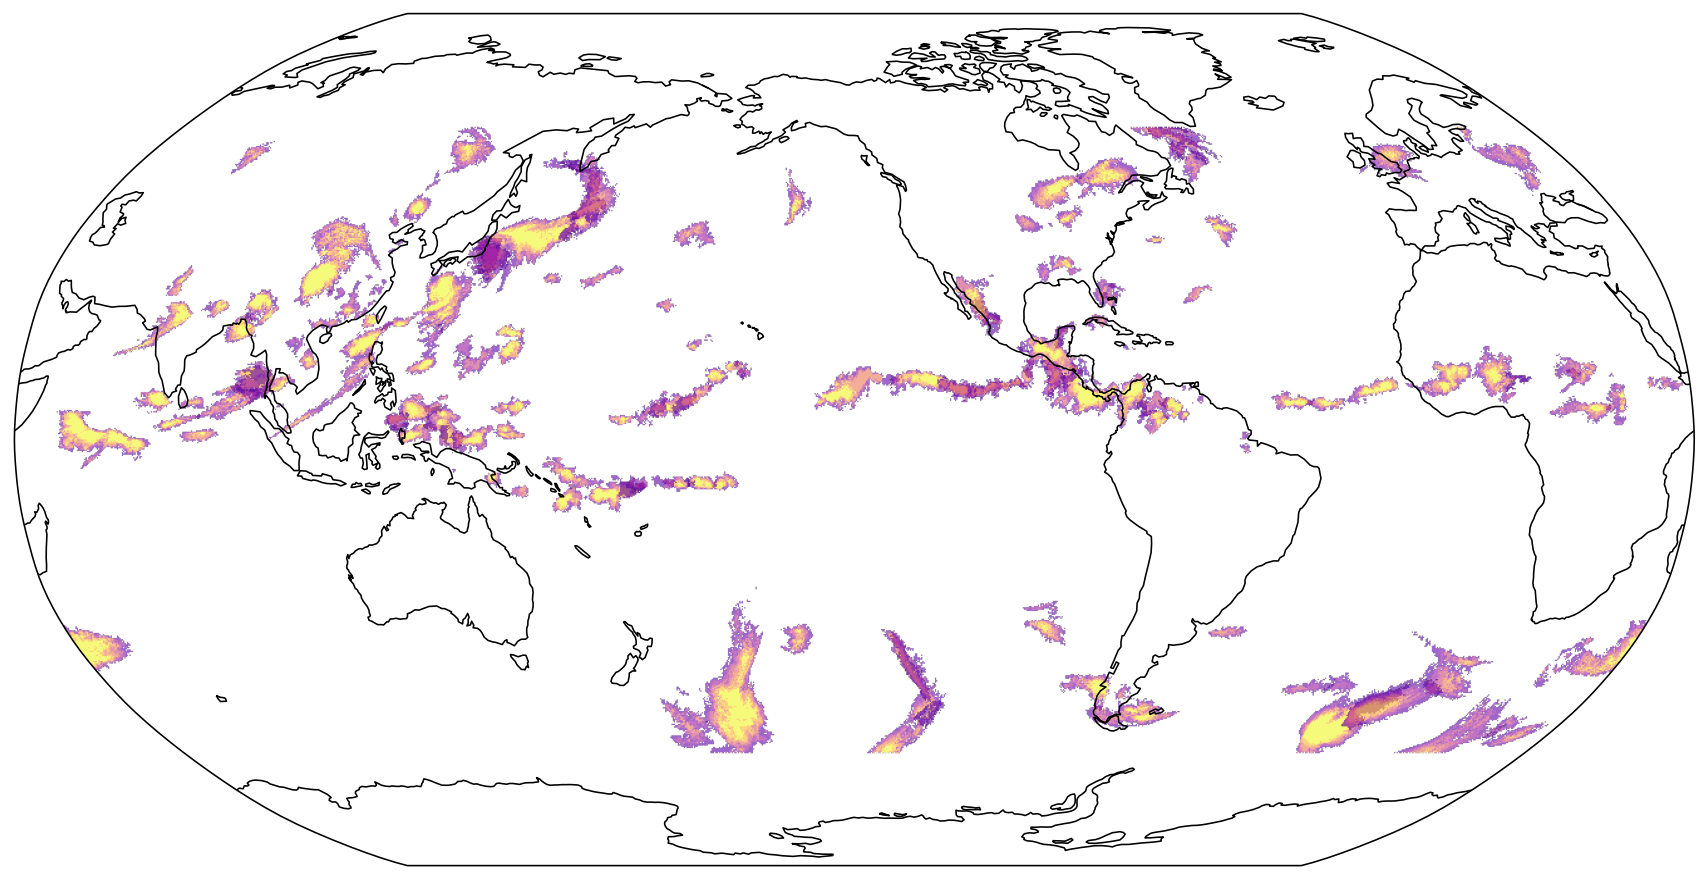

In [51]:
projection = ccrs.Robinson(central_longitude=-135)
fig, ax = plt.subplots(
    figsize=(12,6),
    subplot_kw={"projection": projection},
    constrained_layout=True
)
# fig.dpi = dpi
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)

colormaps = 'plasma'
for i, track_id in enumerate(unique_tracks):
    print(i, track_id)
    coverage = track_coverage_dict[track_id]
    # Convert to DataArray, attach coordinates
    coverage = xr.DataArray(coverage, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
    img = egh.healpix_show(coverage.where(coverage > 0), vmin=0, vmax=6, cmap=colormaps, alpha=0.6, ax=ax)

### 4. Combine Swaths with Overlap Resolution

This section creates a function to combine all track swaths into a single 2D array, resolving overlaps by assigning the track number with the largest coverage count.

In [52]:
def combine_swaths_with_priority(track_swaths_dict, track_coverage_dict):
    """
    Combine multiple track swaths into a single 2D array, resolving overlaps
    by assigning the track number with the largest coverage count.
    
    Parameters:
    -----------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values
    
    Returns:
    --------
    combined_swath : numpy.ndarray
        2D array with combined swaths, where overlapping pixels are assigned
        to the track with the highest coverage count
    """
    # Get the shape from the first swath
    first_key = list(track_swaths_dict.keys())[0]
    shape = track_swaths_dict[first_key].shape
    
    # Initialize output array
    combined_swath = np.zeros(shape, dtype=int)
    
    # Initialize array to track maximum coverage at each pixel
    max_coverage = np.zeros(shape, dtype=int)
    
    # Process each track using vectorized operations
    for track_id in track_swaths_dict.keys():
        # Get swath and coverage for this track
        swath = track_swaths_dict[track_id]
        coverage = track_coverage_dict[track_id]
        
        # Create mask for pixels belonging to this track's swath
        track_mask = swath > 0
        
        # Update combined_swath where:
        # 1. Current pixel has no assignment yet (combined_swath == 0), OR
        # 2. Current track has higher coverage than previous assignment
        update_mask = track_mask & ((combined_swath == 0) | (coverage > max_coverage))
        
        # Apply updates using vectorized operations
        combined_swath = np.where(update_mask, track_id, combined_swath)
        max_coverage = np.where(update_mask, coverage, max_coverage)
    
    return combined_swath

In [69]:
%%timeit

# Apply the function to combine all swaths
combined_swath = combine_swaths_with_priority(track_swaths_dict, track_coverage_dict)

310 ms ± 9.54 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [72]:
# Print summary statistics
print(f"Combined swath shape: {combined_swath.shape}")
print(f"Unique track numbers in combined swath: {np.unique(combined_swath)}")
print(f"Total pixels assigned: {np.sum(combined_swath > 0)}")

# Count pixels per track in the combined swath
for track_id in unique_tracks:
    pixel_count = np.sum(combined_swath == track_id)
    print(f"Track {track_id}: {pixel_count} pixels in combined swath")

Combined swath shape: (786432,)
Unique track numbers in combined swath: [   0  479  759  962 1037 1154 1255 1276 1287 1302 1303 1306 1325 1332
 1335 1340 1343 1345 1350 1356 1359 1360 1367 1373 1375 1379 1383 1391
 1394 1398 1399 1400 1401 1403 1410 1411 1412 1413 1414 1416 1417 1418
 1421 1425 1428 1429 1432 1434 1436 1437 1440 1441 1442 1446 1447 1448
 1449 1450 1452 1454 1455 1456 1458 1459 1460 1462 1463 1464 1467 1468
 1469 1472 1473 1474 1475 1476 1477 1478 1479 1480 1481 1482 1484 1485
 1486 1487 1488 1489 1490 1491 1492 1493 1494 1495 1496 1497 1498 1499
 1500 1501 1502 1503 1504 1505 1506 1507 1508 1509 1510 1511 1512 1513
 1514 1515 1516 1517 1518 1519 1520 1521 1522 1523 1524 1525 1526 1527
 1528 1529 1530 1531 1532 1533 1534 1535 1536 1537 1538 1539 1540 1541
 1542]
Total pixels assigned: 61822
Track 479: 325 pixels in combined swath
Track 759: 909 pixels in combined swath
Track 962: 448 pixels in combined swath
Track 1037: 2 pixels in combined swath
Track 1154: 2133 pixels

### 5. Visualized the combined swath

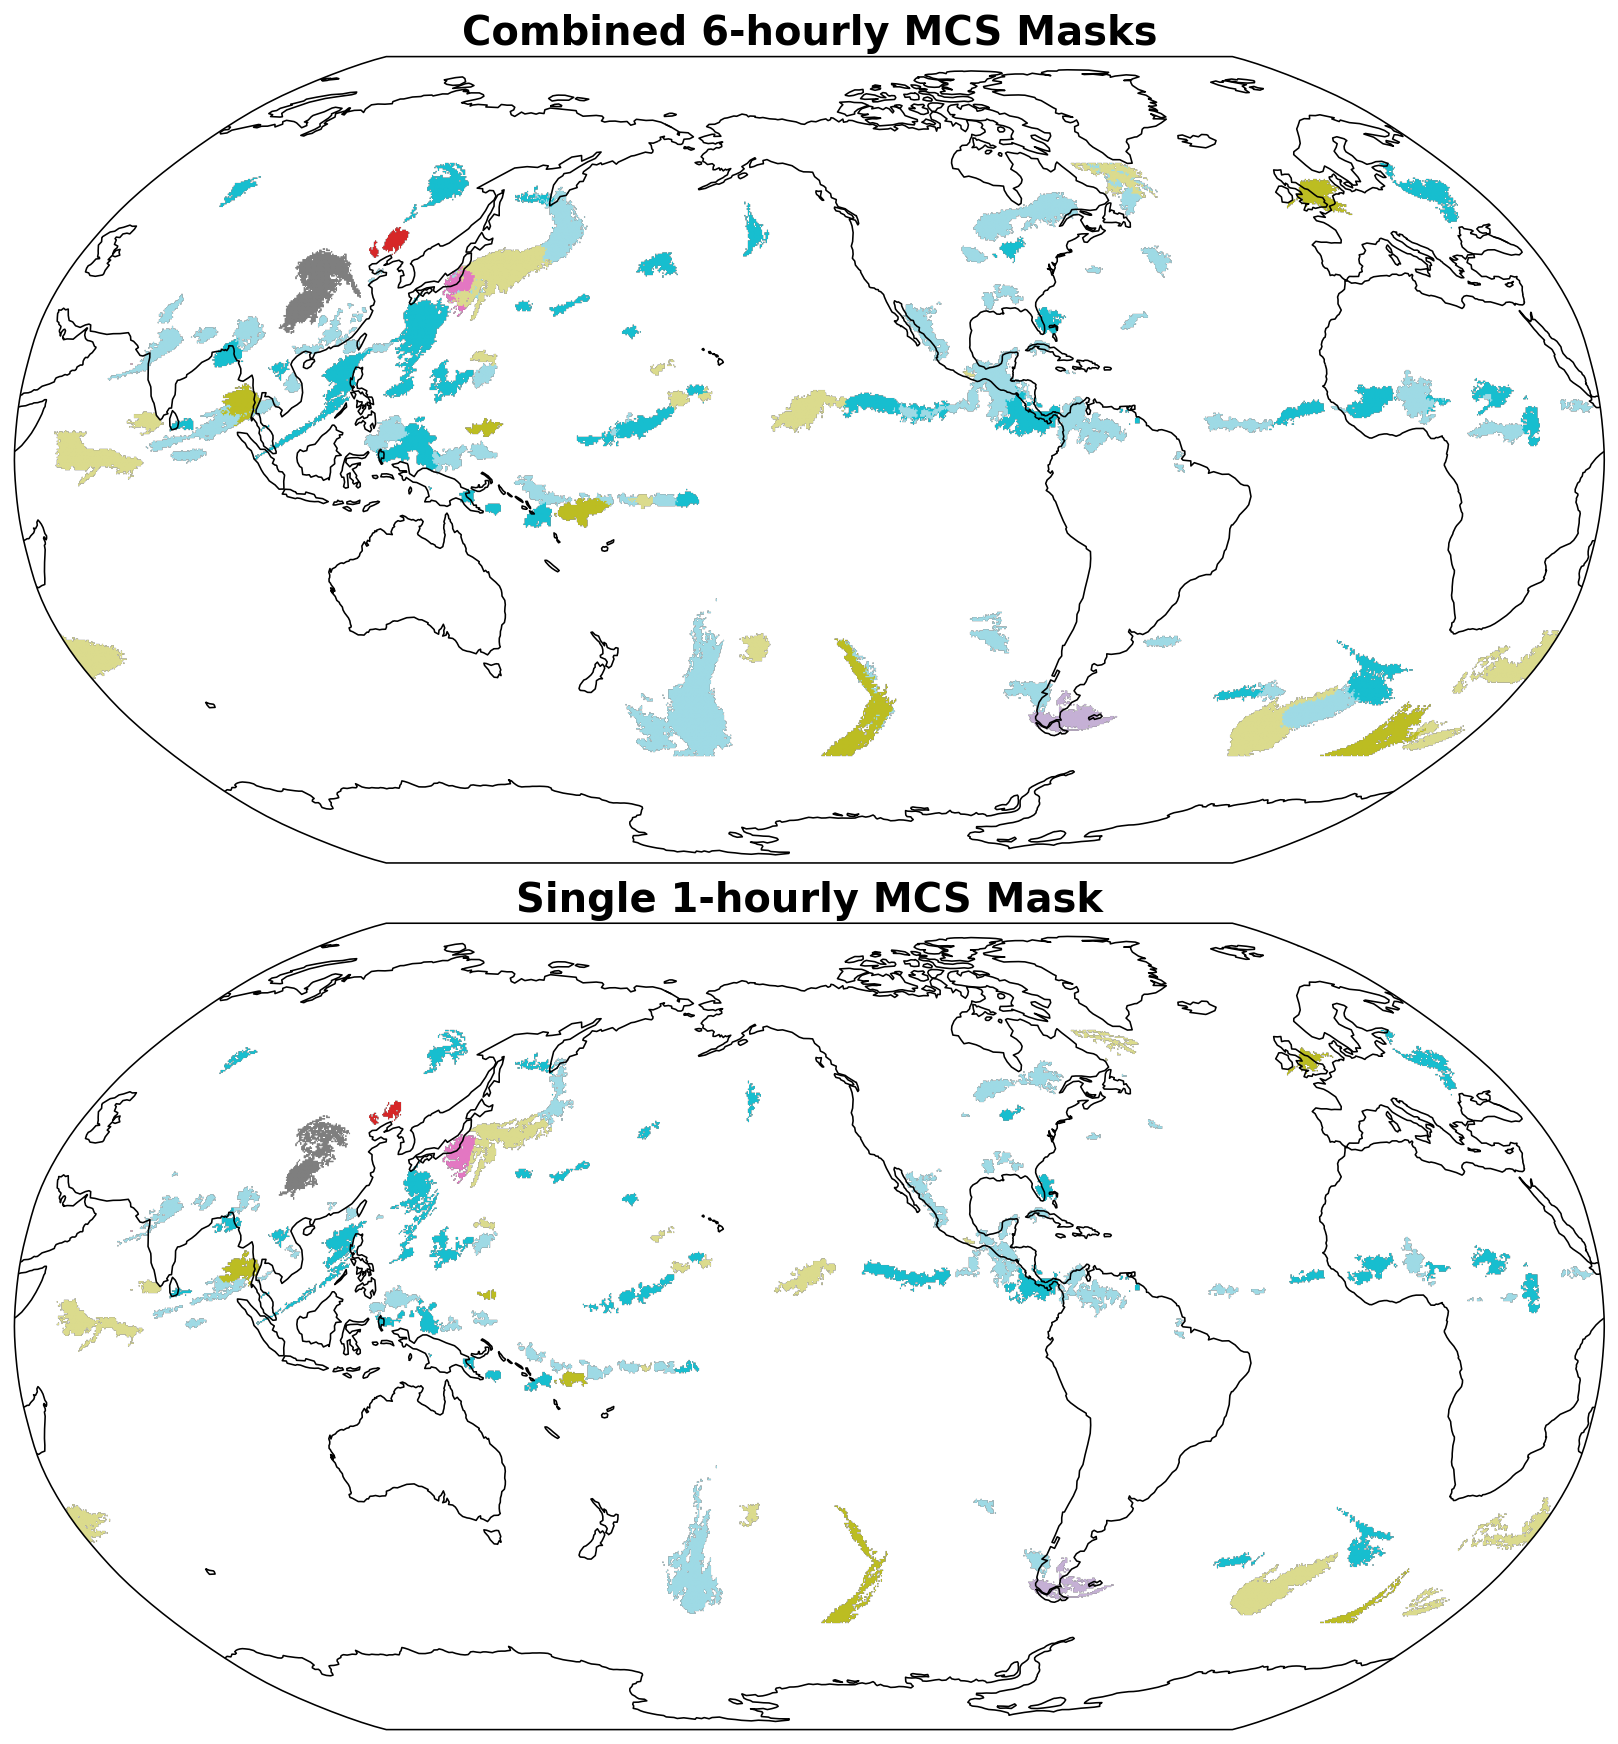

In [75]:
projection = ccrs.Robinson(central_longitude=-135)
fig, axes = plt.subplots(
    2, 1,
    figsize=(12,12),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

# Panel 1: Combined Track Swath
ax = axes[0]
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_title("Combined 6-hourly MCS Masks", fontsize=20, fontweight='bold')
# Normalize color scale
norm = mpl.colors.Normalize(vmin=np.min(combined_swath), vmax=np.max(combined_swath))
# Plot
_combined_swath = xr.DataArray(combined_swath, dims=['cell'], coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
img = egh.healpix_show(_combined_swath.where(_combined_swath > 0), norm=norm, cmap='tab20', ax=ax)

# Panel 2: Single time MCS mask
ax = axes[1]
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_title("Single 1-hourly MCS Mask", fontsize=20, fontweight='bold')
# Plot
_mask = _mcs_mask.isel(time=0)
img = egh.healpix_show(_mask.where(_mask > 0), norm=norm, cmap='tab20', ax=ax)